# WHFast-HJ and close encounters

This notebook asks a narrower question than `0729_comparison_fixed_hierarchy.ipynb`: **does supplying the initial binary tree to WHFast-HJ help when the system undergoes a close encounter?** We compare ordinary WHFast, fixed-tree WHFast-HJ, automatically rebuilt WHFast-HJ, and IAS15.

The answer may change during one trajectory. A fixed tree can be advantageous before an encounter, yet become physically wrong after an exchange or cross-branch passage. We therefore measure encounter geometry and final outcome as well as energy.

### Literature behind the cases

- The two-giant-planet setup uses the masses and orbital scales from the close-encounter test in [Rein et al. (2019), *Hybrid Symplectic Integrators for Planetary Dynamics*](https://arxiv.org/abs/1903.04972).
- Equal-mass binary–single scattering is a standard stellar-dynamics experiment following [Hut & Bahcall (1983)](https://adsabs.harvard.edu/pdf/1983ApJ...268..319H).
- Binary–binary encounters are motivated by numerical scattering studies such as [Fregeau et al. (2004)](https://onlinelibrary.wiley.com/doi/10.1111/j.1365-2966.2004.07914.x).
- The Pythagorean problem is a classical chaotic, non-hierarchical three-body benchmark; see, for example, [Boekholt et al. (2021)](https://arxiv.org/abs/2109.07013).
- Close encounters are precisely where ordinary Wisdom–Holman splitting becomes inaccurate and hybrid methods are normally used: [Chambers (1999)](https://doi.org/10.1046/j.1365-8711.1999.02379.x), [MERCURIUS](https://arxiv.org/abs/1903.04972), and [TRACE](https://arxiv.org/abs/2405.03800). IAS15 is used here because it is adaptive and designed to resolve close approaches ([Rein & Spiegel 2015](https://arxiv.org/abs/1409.4779)).

> The literature-inspired cases below are deterministic, rescaled tests, not exact reproductions of published ensembles. Point masses are used and physical collisions are not resolved.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import itertools
import os
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
repo_root = next(p for p in (cwd, *cwd.parents)
                 if (p / "rebound").is_dir() and (p / "src").is_dir())
sys.path.insert(0, str(repo_root))
import rebound

QUICK = os.environ.get("REBOUND_BENCHMARK_QUICK", "0") == "1"
DIVISORS = (20, 40) if QUICK else (20, 40, 80, 160)
MAIN_DIVISOR = 40
N_OUTPUT = 100 if QUICK else 800
REFERENCE_SAMPLES = 800 if QUICK else 10000
ENERGY_FLOOR = 5e-16
MODES = ("whfast", "hj_fixed", "hj_auto")
COLORS = {"whfast":"#d95f02", "hj_fixed":"#1b9e77",
          "hj_auto":"#7570b3", "ias15":"#3b5bdb"}
LABELS = {"whfast":"WHFast", "hj_fixed":"HJ fixed tree",
          "hj_auto":"HJ automatic tree", "ias15":"IAS15"}

print("rebound Python:", rebound.__file__)
print("rebound library:", rebound.__libpath__)
print("mode:", "QUICK validation" if QUICK else "FULL encounter benchmark")
print("divisors:", DIVISORS, "outputs:", N_OUTPUT,
      "IAS15 encounter samples:", REFERENCE_SAMPLES)

rebound Python: /Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/rebound/__init__.py
rebound library: /Users/ziruiliu/Ray/school/2026_summer/Hanno/rebound/librebound.so
mode: FULL encounter benchmark
divisors: (20, 40, 80, 160) outputs: 800 IAS15 encounter samples: 10000


## Initial conditions and trees

Every case supplies an initial tree. Ordinary WHFast sees only the listed particle order. Fixed HJ receives that tree once. Automatic HJ starts from the same particles but discovers its hierarchy internally. IAS15 receives no tree.

The reference period only defines the fixed timestep; it is not assumed to remain a valid orbital period after scattering.

In [2]:
@dataclass(frozen=True)
class EncounterCase:
    key: str
    title: str
    description: str
    particles: dict
    order: tuple
    tree: object
    encounter_pairs: tuple
    reference_period: float
    duration: float
    expected: str
    source_label: str
    source_url: str


def detached_particle(particle):
    return rebound.Particle(m=particle.m, x=particle.x, y=particle.y, z=particle.z,
                            vx=particle.vx, vy=particle.vy, vz=particle.vz)


def copied_particles(sim, names):
    sim.move_to_com()
    return {name: detached_particle(particle) for name, particle in zip(names, sim.particles)}


def shift_particle(particle, x=0, y=0, z=0, vx=0, vy=0, vz=0):
    p = detached_particle(particle)
    p.x += x; p.y += y; p.z += z
    p.vx += vx; p.vy += vy; p.vz += vz
    return p


def binary_particles(m1, m2, a, e=0, inc=0, f=0):
    sim = rebound.Simulation(); sim.G = 1.0
    sim.add(m=m1)
    sim.add(m=m2, a=a, e=e, inc=np.deg2rad(inc), f=np.deg2rad(f))
    sim.move_to_com()
    return detached_particle(sim.particles[0]), detached_particle(sim.particles[1])


def planet_encounter_case():
    # Rein et al. (2019) masses and a,e scales; deterministic aligned phase.
    sim = rebound.Simulation(); sim.G = 1.0
    sim.add(m=1.0)
    sim.add(m=1e-3, a=1.0, e=.1, f=0)
    sim.add(m=1e-3, a=1.1, e=.2, f=0)
    names = ("Sun", "inner planet", "outer planet")
    period = 2*np.pi*np.sqrt(1.0**3/1.001)
    return EncounterCase(
        "01_rein_planets", "Two giant planets on crossing orbits",
        "MERCURIUS-paper-inspired pair of Jupiter-mass planets; the chosen phase produces a strong planet–planet encounter.",
        copied_particles(sim, names), names, [["Sun","inner planet"],"outer planet"],
        (("inner planet","outer planet"),),
        period, 20*period, "tree likely changes",
        "Rein et al. 2019", "https://arxiv.org/abs/1903.04972")


def binary_single_case():
    a, b = binary_particles(1, 1, a=1, e=.1, f=30)
    sim = rebound.Simulation(); sim.G = 1.0
    sim.add(shift_particle(a, x=2.5))
    sim.add(shift_particle(b, x=2.5))
    sim.add(m=1, x=-7.5, y=.45, vx=.75)
    names = ("A", "B", "intruder")
    period = 2*np.pi*np.sqrt(1/2)
    return EncounterCase(
        "02_binary_single", "Equal-mass binary–single scattering",
        "A hard equal-mass binary is struck by an incoming equal-mass star at nonzero impact parameter.",
        copied_particles(sim, names), names, [["A","B"],"intruder"],
        (("A","intruder"),("B","intruder")),
        period, 8*period, "exchange or resonant scattering",
        "Hut & Bahcall 1983", "https://adsabs.harvard.edu/pdf/1983ApJ...268..319H")


def binary_binary_case():
    a1, a2 = binary_particles(1, 1, a=.6, e=.1, f=10)
    b1, b2 = binary_particles(1, 1, a=.6, e=.1, inc=35, f=190)
    sim = rebound.Simulation(); sim.G = 1.0
    for p in (a1,a2): sim.add(shift_particle(p, x=-4, y=-.3, vx=.45))
    for p in (b1,b2): sim.add(shift_particle(p, x=4, y=.3, vx=-.45))
    names = ("A1","A2","B1","B2")
    period = 2*np.pi*np.sqrt(.6**3/2)
    return EncounterCase(
        "03_binary_binary", "Binary–binary close scattering",
        "Two inclined equal-mass hard binaries approach with a modest impact parameter.",
        copied_particles(sim, names), names, [["A1","A2"],["B1","B2"]],
        (("A1","B1"),("A1","B2"),("A2","B1"),("A2","B2")),
        period, 10*period, "branches may exchange members",
        "Fregeau et al. 2004", "https://onlinelibrary.wiley.com/doi/10.1111/j.1365-2966.2004.07914.x")


def eccentric_binary_binary_case():
    a1,a2=binary_particles(1.0,.8,a=.45,e=.1,f=20)
    b1,b2=binary_particles(.9,.7,a=.55,e=.1,inc=25,f=140)
    outer=rebound.Simulation(); outer.G=1
    outer.add(m=1.8); outer.add(m=1.6,a=6,e=.55,inc=np.deg2rad(20),f=np.pi)
    outer.move_to_com()
    sim=rebound.Simulation(); sim.G=1
    for p in (a1,a2):
        sim.add(shift_particle(p,x=outer.particles[0].x,y=outer.particles[0].y,z=outer.particles[0].z,
                               vx=outer.particles[0].vx,vy=outer.particles[0].vy,vz=outer.particles[0].vz))
    for p in (b1,b2):
        sim.add(shift_particle(p,x=outer.particles[1].x,y=outer.particles[1].y,z=outer.particles[1].z,
                               vx=outer.particles[1].vx,vy=outer.particles[1].vy,vz=outer.particles[1].vz))
    names=("A1","A2","B1","B2")
    pmin=min(2*np.pi*np.sqrt(.45**3/1.8),2*np.pi*np.sqrt(.55**3/1.6))
    ptop=2*np.pi*np.sqrt(6**3/3.4)
    return EncounterCase(
        "04_eccentric_2plus2", "Hierarchy-preserving eccentric 2+2 near miss",
        "Two tight binaries make repeated inclined pericentre passages while remaining well enough separated to preserve both branches.",
        copied_particles(sim,names),names,[["A1","A2"],["B1","B2"]],
        (("A1","B1"),("A1","B2"),("A2","B1"),("A2","B2")),
        pmin,2*ptop,"initial branching hierarchy survives",
        "nested-binary hierarchy formalism","https://arxiv.org/abs/1511.00944")


def cross_branch_case():
    # The unstable case 8 diagnosed in the 0729 notebook.
    left = rebound.Simulation(); left.G=1
    left.add(m=1); left.add(m=.6,a=.8,e=.1)
    left.add(m=.001,a=3.5,e=.03,inc=np.deg2rad(4)); left.move_to_com()
    right = rebound.Simulation(); right.G=1
    right.add(m=.9); right.add(m=.5,a=1,e=.08,inc=np.deg2rad(15))
    right.add(m=.001,a=4,e=.04,inc=np.deg2rad(18)); right.move_to_com()
    outer = rebound.Simulation(); outer.G=1
    outer.add(m=1.601); outer.add(m=1.401,a=15,e=.1,inc=np.deg2rad(25)); outer.move_to_com()
    sim = rebound.Simulation(); sim.G=1
    for p in left.particles: sim.add(shift_particle(p, x=outer.particles[0].x, y=outer.particles[0].y, z=outer.particles[0].z, vx=outer.particles[0].vx, vy=outer.particles[0].vy, vz=outer.particles[0].vz))
    for p in right.particles: sim.add(shift_particle(p, x=outer.particles[1].x, y=outer.particles[1].y, z=outer.particles[1].z, vx=outer.particles[1].vx, vy=outer.particles[1].vy, vz=outer.particles[1].vz))
    names=("A1","A2","A planet","B1","B2","B planet")
    pmin=2*np.pi*np.sqrt(.8**3/1.6); ptop=2*np.pi*np.sqrt(15**3/3.002)
    tree=[[['A1','A2'],'A planet'],[['B1','B2'],'B planet']]
    return EncounterCase(
        "05_cross_branch", "Cross-branch planet encounter",
        "The unstable twin-circumbinary case from 0729; a planet penetrates the opposite stellar branch.",
        copied_particles(sim,names), names, tree,
        tuple((a,b) for a in names[:3] for b in names[3:]), pmin, 3*ptop,
        "fixed tree becomes invalid", "0729 case-8 follow-up",
        "https://arxiv.org/abs/1903.04972")


def pythagorean_case():
    sim=rebound.Simulation(); sim.G=1
    sim.add(m=3,x=1,y=3); sim.add(m=4,x=-2,y=-1); sim.add(m=5,x=1,y=-1)
    names=("m3","m4","m5")
    return EncounterCase(
        "06_pythagorean", "Pythagorean three-body problem",
        "Masses 3, 4, 5 start from rest at the vertices of a 3-4-5 triangle. The initial nearest-pair tree is only a bookkeeping choice.",
        copied_particles(sim,names), names, [["m4","m5"],"m3"],
        tuple(itertools.combinations(names,2)),
        1.0, 10.0, "non-hierarchical chaotic encounter",
        "Pythagorean benchmark", "https://arxiv.org/abs/2109.07013")


CASES=[planet_encounter_case(), binary_single_case(), binary_binary_case(),
       eccentric_binary_binary_case(), cross_branch_case(), pythagorean_case()]
print("encounter cases:",len(CASES))

encounter cases: 6


In [3]:
for number, case in enumerate(CASES,1):
    display(Markdown(
        f"### {number}. {case.title}\n\n{case.description}\n\n"
        f"**Expected:** {case.expected}.  **Initial tree:** `{case.tree}`.\n\n"
        f"Source: [{case.source_label}]({case.source_url})"))
    print("order:",case.order,"duration/P_ref:",case.duration/case.reference_period)

### 1. Two giant planets on crossing orbits

MERCURIUS-paper-inspired pair of Jupiter-mass planets; the chosen phase produces a strong planet–planet encounter.

**Expected:** tree likely changes.  **Initial tree:** `[['Sun', 'inner planet'], 'outer planet']`.

Source: [Rein et al. 2019](https://arxiv.org/abs/1903.04972)

order: ('Sun', 'inner planet', 'outer planet') duration/P_ref: 20.0


### 2. Equal-mass binary–single scattering

A hard equal-mass binary is struck by an incoming equal-mass star at nonzero impact parameter.

**Expected:** exchange or resonant scattering.  **Initial tree:** `[['A', 'B'], 'intruder']`.

Source: [Hut & Bahcall 1983](https://adsabs.harvard.edu/pdf/1983ApJ...268..319H)

order: ('A', 'B', 'intruder') duration/P_ref: 8.0


### 3. Binary–binary close scattering

Two inclined equal-mass hard binaries approach with a modest impact parameter.

**Expected:** branches may exchange members.  **Initial tree:** `[['A1', 'A2'], ['B1', 'B2']]`.

Source: [Fregeau et al. 2004](https://onlinelibrary.wiley.com/doi/10.1111/j.1365-2966.2004.07914.x)

...

order: ('A1', 'A2', 'B1', 'B2') duration/P_ref: 70.84919084320762


### 5. Cross-branch planet encounter

The unstable twin-circumbinary case from 0729; a planet penetrates the opposite stellar branch.

**Expected:** fixed tree becomes invalid.  **Initial tree:** `[[['A1', 'A2'], 'A planet'], [['B1', 'B2'], 'B planet']]`.

Source: [0729 case-8 follow-up](https://arxiv.org/abs/1903.04972)

order: ('A1', 'A2', 'A planet', 'B1', 'B2', 'B planet') duration/P_ref: 177.8188553082356


### 6. Pythagorean three-body problem

Masses 3, 4, 5 start from rest at the vertices of a 3-4-5 triangle. The initial nearest-pair tree is only a bookkeeping choice.

**Expected:** non-hierarchical chaotic encounter.  **Initial tree:** `[['m4', 'm5'], 'm3']`.

Source: [Pythagorean benchmark](https://arxiv.org/abs/2109.07013)

order: ('m3', 'm4', 'm5') duration/P_ref: 10.0


## Diagnostics

`r_min` is the smallest sampled separation among the designated encounter pairs and `t_enc` its time. `dx` and `dv` compare the complete sampled trajectory with IAS15, with position and velocity normalized separately. `|dL|` is the maximum absolute angular-momentum-vector drift; an absolute value is used because the Pythagorean initial condition has zero total angular momentum. `outcome` is the set of gravitationally bound pairs at the final sample; in a many-body encounter it is a compact fingerprint, not a complete hierarchy classifier.

Warnings and non-finite states are retained as failures. A lower energy error alone is not counted as success if the encounter geometry or final bound outcome disagrees with IAS15.

In [4]:
def tree_to_indices(tree,order):
    indices={name:i+1 for i,name in enumerate(order)}
    def convert(item):
        return indices[item] if isinstance(item,str) else [convert(item[0]),convert(item[1])]
    return convert(tree)


def make_simulation(case,mode,divisor=MAIN_DIVISOR):
    sim=rebound.Simulation(); sim.G=1.0
    for name in case.order: sim.add(case.particles[name])
    sim.move_to_com(); sim.dt=case.reference_period/divisor
    if mode=="ias15":
        sim.integrator="ias15"; sim.integrator.epsilon=1e-12
    elif mode=="whfast": sim.integrator="whfast"
    else: sim.integrator="whfast_hj"
    tree=tree_to_indices(case.tree,case.order)
    if mode=="hj_fixed": sim.integrate(sim.t,given_tree=True,tree=tree)
    return sim,tree


def state_array(sim):
    sim.synchronize()
    return np.asarray([[p.x,p.y,p.z,p.vx,p.vy,p.vz] for p in sim.particles])


def angular_momentum_array(sim):
    L=sim.angular_momentum()
    return np.asarray([L.x,L.y,L.z],dtype=float)


def closest_pair(sim,names,allowed_pairs=None):
    allowed = None if allowed_pairs is None else {frozenset(pair) for pair in allowed_pairs}
    best=(np.inf,None)
    for i,j in itertools.combinations(range(sim.N),2):
        if allowed is not None and frozenset((names[i],names[j])) not in allowed: continue
        p,q=sim.particles[i],sim.particles[j]
        d=np.sqrt((p.x-q.x)**2+(p.y-q.y)**2+(p.z-q.z)**2)
        if d<best[0]: best=(float(d),(names[i],names[j]))
    return best


def bound_pairs(sim,names):
    pairs=[]
    for i,j in itertools.combinations(range(sim.N),2):
        p,q=sim.particles[i],sim.particles[j]
        dr=np.asarray([p.x-q.x,p.y-q.y,p.z-q.z])
        dv=np.asarray([p.vx-q.vx,p.vy-q.vy,p.vz-q.vz])
        specific=.5*np.dot(dv,dv)-sim.G*(p.m+q.m)/np.linalg.norm(dr)
        if specific<0: pairs.append(tuple(sorted((names[i],names[j]))))
    return tuple(sorted(pairs))


def normalized_trajectory_errors(states,reference_states):
    a=np.asarray(states); b=np.asarray(reference_states)
    dx=np.sqrt(np.mean((a[:,:,:3]-b[:,:,:3])**2))
    dv=np.sqrt(np.mean((a[:,:,3:]-b[:,:,3:])**2))
    sx=max(np.sqrt(np.mean(b[:,:,:3]**2)),np.finfo(float).eps)
    sv=max(np.sqrt(np.mean(b[:,:,3:]**2)),np.finfo(float).eps)
    return dx/sx,dv/sv


def common_schedule(case):
    coarse=min(DIVISORS); dt=case.reference_period/coarse
    steps=max(1,int(np.ceil(case.duration/dt)))
    marks=np.unique(np.linspace(1,steps,N_OUTPUT,dtype=int))
    return dt,steps,marks,marks*dt


## IAS15 references and encounter audit

IAS15 is sampled on the common comparison schedule for trajectory errors and on a denser grid for closest-approach diagnostics. The dense `r_min` is still a sampled upper bound on the true minimum separation.

In [5]:
REFERENCES={}
for case in CASES:
    dt0,coarse_steps,marks,times=common_schedule(case)
    sim,_=make_simulation(case,"ias15")
    states=[]; energy=[]; e0=sim.energy(); L0=angular_momentum_array(sim)
    start=time.perf_counter()
    for target in times:
        sim.integrate(target,exact_finish_time=1)
        states.append(state_array(sim)); energy.append(max(abs((sim.energy()-e0)/e0),ENERGY_FLOOR))
    runtime=time.perf_counter()-start
    final_outcome=bound_pairs(sim,case.order)

    dense,_=make_simulation(case,"ias15")
    rmin=np.inf; pair=None; tenc=0.0; vrel=np.nan
    for target in np.linspace(case.duration/REFERENCE_SAMPLES,case.duration,REFERENCE_SAMPLES):
        dense.integrate(target,exact_finish_time=1)
        distance,names=closest_pair(dense,case.order,case.encounter_pairs)
        if distance<rmin:
            rmin,pair,tenc=distance,names,dense.t
            i,j=(case.order.index(name) for name in names)
            p,q=dense.particles[i],dense.particles[j]
            vrel=float(np.linalg.norm([p.vx-q.vx,p.vy-q.vy,p.vz-q.vz]))
    REFERENCES[case.key]={"times":times,"states":np.asarray(states),
        "energy":np.asarray(energy),"rmin":rmin,"pair":pair,"tenc":tenc,
        "vrel":vrel,"outcome":final_outcome,"runtime":runtime}
    print(f"{case.key:22s} IAS15 r_min={rmin:.3e} pair={pair} "
          f"t_enc/P_ref={tenc/case.reference_period:.3f} outcome={final_outcome}")

01_rein_planets        IAS15 r_min=2.049e-04 pair=('inner planet', 'outer planet') t_enc/P_ref=11.580 outcome=(('Sun', 'inner planet'), ('Sun', 'outer planet'), ('inner planet', 'outer planet'))
02_binary_single       IAS15 r_min=6.285e-02 pair=('B', 'intruder') t_enc/P_ref=6.956 outcome=(('A', 'B'), ('A', 'intruder'), ('B', 'intruder'))
03_binary_binary       IAS15 r_min=8.983e-02 pair=('A1', 'B2') t_enc/P_ref=6.595 outcome=(('A1', 'B2'), ('A2', 'B2'))
04_eccentric_2plus2    IAS15 r_min=2.151e+00 pair=('A1', 'B2') t_enc/P_ref=17.415 outcome=(('A1', 'A2'), ('A1', 'B1'), ('B1', 'B2'))
05_cross_branch        IAS15 r_min=1.349e-01 pair=('A2', 'B planet') t_enc/P_ref=97.142 outcome=(('A1', 'A2'), ('B1', 'B2'))
06_pythagorean         IAS15 r_min=1.149e-02 pair=('m4', 'm5') t_enc/P_ref=8.760 outcome=(('m3', 'm5'), ('m4', 'm5'))


## Fixed-step comparisons and timestep convergence

All divisors end at the same time and are sampled at the same physical epochs. Runs are marked failed if REBOUND emits a warning, raises an exception, or produces a non-finite diagnostic. Runtime includes the sampled trajectory and is therefore useful only for relative comparison within this cell.

In [6]:
def run_fixed_case(case,mode,divisor):
    ref=REFERENCES[case.key]; dt0,coarse_steps,coarse_marks,times=common_schedule(case)
    multiplier=divisor//min(DIVISORS)
    marks=coarse_marks*multiplier
    sim,_=make_simulation(case,mode,divisor)
    e0=sim.energy(); L0=angular_momentum_array(sim)
    previous=0; energies=[]; angular=[]; states=[]; separations=[]; pairs=[]
    rmin=np.inf; encounter_pair=None; tenc=0.0
    start=time.perf_counter()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error")
            for mark in marks:
                for _ in range(int(mark-previous)):
                    sim.steps(1); sim.synchronize()
                    distance,pair=closest_pair(sim,case.order,case.encounter_pairs)
                    if distance<rmin:
                        rmin,encounter_pair,tenc=distance,pair,sim.t
                previous=int(mark)
                energies.append(max(abs((sim.energy()-e0)/e0),ENERGY_FLOOR))
                angular.append(np.linalg.norm(angular_momentum_array(sim)-L0))
                states.append(state_array(sim))
                distance,pair=closest_pair(sim,case.order,case.encounter_pairs); separations.append(distance); pairs.append(pair)
        values=np.asarray(energies); states=np.asarray(states); separations=np.asarray(separations)
        if not (np.all(np.isfinite(values)) and np.all(np.isfinite(states))):
            raise FloatingPointError("non-finite trajectory")
        dx,dv=normalized_trajectory_errors(states,ref["states"])
        outcome=bound_pairs(sim,case.order)
        return {"case":case.key,"mode":mode,"divisor":divisor,"failed":False,
            "time":times/case.reference_period,"energy":values,"angular":np.asarray(angular),
            "separation":separations,"pairs":pairs,"states":states,
            "max_energy":float(values.max()),"rms_energy":float(np.sqrt(np.mean(values**2))),
            "max_angular":float(np.max(angular)),"dx":float(dx),"dv":float(dv),
            "rmin":float(rmin),"pair":encounter_pair,"tenc":float(tenc),
            "rmin_error":abs(rmin-ref["rmin"])/max(ref["rmin"],np.finfo(float).eps),
            "tenc_error":abs(tenc-ref["tenc"])/case.reference_period,
            "outcome":outcome,"outcome_match":outcome==ref["outcome"],
            "runtime":time.perf_counter()-start}
    except Exception as exc:
        return {"case":case.key,"mode":mode,"divisor":divisor,"failed":True,
                "failure":f"{type(exc).__name__}: {exc}","runtime":time.perf_counter()-start}


RESULTS=[]
for case in CASES:
    print(f"\n{case.key}: {case.title}",flush=True)
    for divisor in DIVISORS:
        for mode in MODES:
            run=run_fixed_case(case,mode,divisor); RESULTS.append(run)
            if run["failed"]:
                print(f"  {mode:9s} P/{divisor:<3d} FAILED {run['failure']}")
            else:
                print(f"  {mode:9s} P/{divisor:<3d} maxE={run['max_energy']:.2e} "
                      f"dx={run['dx']:.2e} dv={run['dv']:.2e} "
                      f"rmin={run['rmin']:.2e} outcome={'match' if run['outcome_match'] else 'DIFF'}")


01_rein_planets: Two giant planets on crossing orbits
  whfast    P/20  maxE=1.20e+00 dx=3.36e+01 dv=1.21e+00 rmin=1.74e-01 outcome=DIFF
  hj_fixed  P/20  maxE=1.20e+00 dx=3.36e+01 dv=1.21e+00 rmin=1.74e-01 outcome=DIFF
  hj_auto   P/20  FAILED RuntimeWarning: Possible convergence issue. Timestep in Kepler solver is larger than one orbital period.
  whfast    P/40  maxE=1.83e-01 dx=1.69e+00 dv=1.28e+00 rmin=4.09e-02 outcome=DIFF
  hj_fixed  P/40  maxE=1.83e-01 dx=1.69e+00 dv=1.28e+00 rmin=4.09e-02 outcome=DIFF
  hj_auto   P/40  maxE=9.31e-03 dx=6.55e-03 dv=2.95e-01 rmin=3.54e-04 outcome=match
  whfast    P/80  maxE=2.95e-01 dx=2.14e+00 dv=1.34e+00 rmin=4.05e-03 outcome=DIFF
  hj_fixed  P/80  maxE=2.95e-01 dx=2.14e+00 dv=1.34e+00 rmin=4.05e-03 outcome=DIFF
  hj_auto   P/80  maxE=1.66e-03 dx=3.43e-03 dv=2.98e-01 rmin=3.33e-04 outcome=match
  whfast    P/160 maxE=1.22e-01 dx=1.56e+00 dv=1.41e+00 rmin=5.00e-03 outcome=DIFF
  hj_fixed  P/160 maxE=1.22e-01 dx=1.56e+00 dv=1.41e+00 rmin=5.00e

## Main-divisor summary

At $P_{\rm ref}/40$, fixed HJ is called **better** only when it lowers both maximum energy error and trajectory position error relative to WHFast, reproduces the IAS15 bound-pair outcome, and does not worsen closest-approach distance by more than a factor of two. This is deliberately stricter than an energy-only label.

In [7]:
def selected(case_key,mode,divisor=MAIN_DIVISOR):
    return next(row for row in RESULTS if row["case"]==case_key and row["mode"]==mode and row["divisor"]==divisor)

header=(f"{'case':22s} {'method':9s} {'maxE':>10s} {'rmsE':>10s} {'|dL|':>9s} "
        f"{'dx':>9s} {'dv':>9s} {'rmin err':>10s} {'dtenc':>9s} {'outcome':>8s}")
print(header); print("-"*len(header))
CLASSIFICATION={}
for case in CASES:
    rows={mode:selected(case.key,mode) for mode in MODES}
    for mode,row in rows.items():
        if row["failed"]:
            print(f"{case.key:22s} {mode:9s} FAILED: {row['failure']}"); continue
        print(f"{case.key:22s} {mode:9s} {row['max_energy']:10.2e} {row['rms_energy']:10.2e} "
              f"{row['max_angular']:9.2e} {row['dx']:9.2e} {row['dv']:9.2e} "
              f"{row['rmin_error']:10.2e} {row['tenc_error']:9.2e} "
              f"{'match' if row['outcome_match'] else 'DIFF':>8s}")
    w,h,a=rows["whfast"],rows["hj_fixed"],rows["hj_auto"]
    if h["failed"]: verdict="fixed HJ failed"
    elif (not w["failed"] and np.isclose(h["max_energy"],w["max_energy"],rtol=1e-8)
          and np.isclose(h["dx"],w["dx"],rtol=1e-8) and h["outcome_match"]):
        verdict="no HJ accuracy advantage"
    elif (not w["failed"] and h["max_energy"]<w["max_energy"] and h["dx"]<w["dx"]
          and h["outcome_match"] and h["rmin_error"]<=2*max(w["rmin_error"],1e-12)):
        verdict="fixed HJ better"
    elif not a["failed"] and a["outcome_match"]:
        verdict="automatic HJ preferred"
    else: verdict="no reliable HJ win"
    CLASSIFICATION[case.key]=verdict
    print("  =>",verdict)

case                   method          maxE       rmsE      |dL|        dx        dv   rmin err     dtenc  outcome
------------------------------------------------------------------------------------------------------------------
01_rein_planets        whfast      1.83e-01   1.83e-01  6.07e-18  1.69e+00  1.28e+00   1.99e+02  1.16e+01     DIFF
01_rein_planets        hj_fixed    1.83e-01   1.83e-01  7.45e-16  1.69e+00  1.28e+00   1.99e+02  1.16e+01     DIFF
01_rein_planets        hj_auto     9.31e-03   4.81e-03  5.29e-16  6.55e-03  2.95e-01   7.29e-01  1.45e-01    match
  => automatic HJ preferred
02_binary_single       whfast      1.51e+02   1.31e+02  4.40e-13  3.13e+01  9.32e+00   1.50e+00  5.01e+00     DIFF
02_binary_single       hj_fixed    1.51e+02   1.31e+02  1.35e-12  3.13e+01  9.32e+00   1.50e+00  5.01e+00     DIFF
02_binary_single       hj_auto     7.93e+00   6.48e+00  2.49e-13  6.38e+00  2.20e+00   1.50e+00  5.01e+00     DIFF
  => no reliable HJ win
03_binary_binary       whfas

### Two giant planets on crossing orbits

**Verdict:** automatic HJ preferred

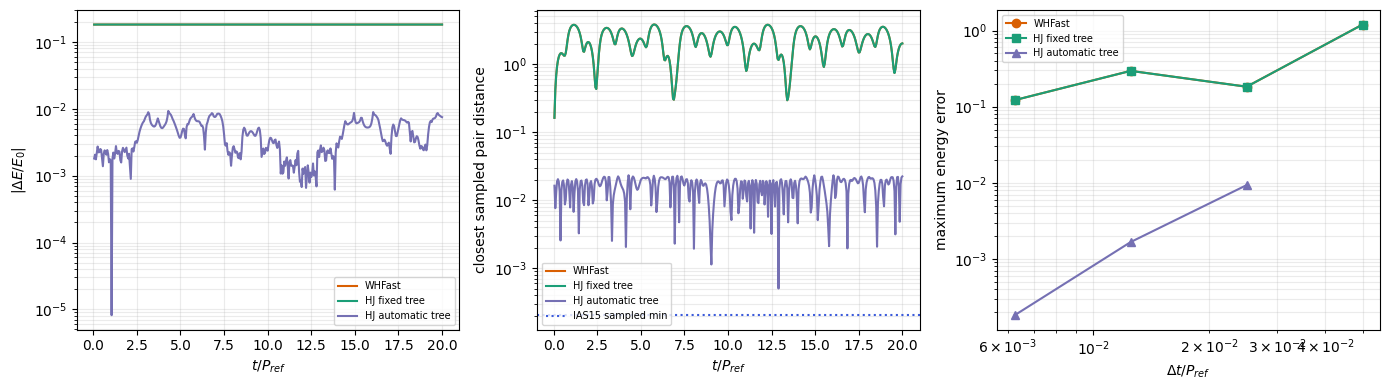

### Equal-mass binary–single scattering

**Verdict:** no reliable HJ win

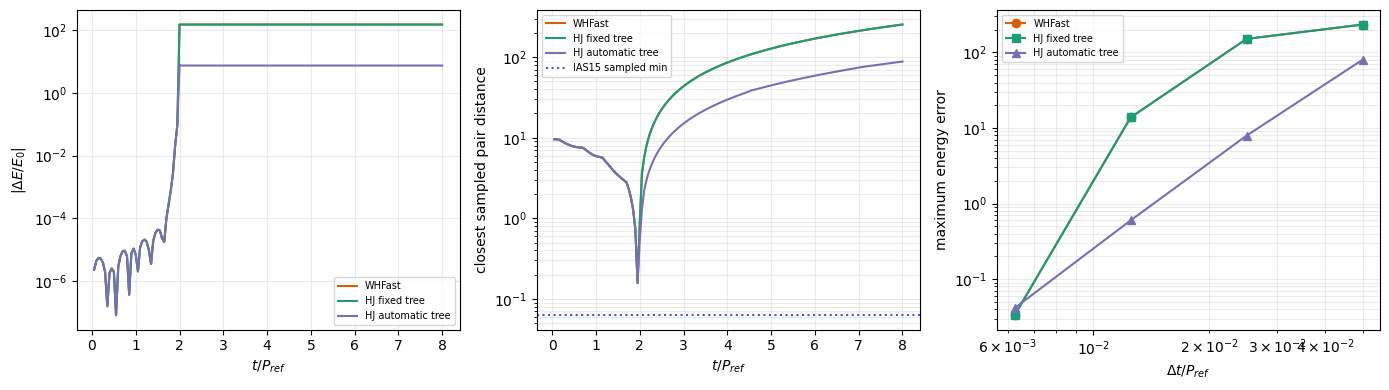

### Binary–binary close scattering

**Verdict:** no reliable HJ win

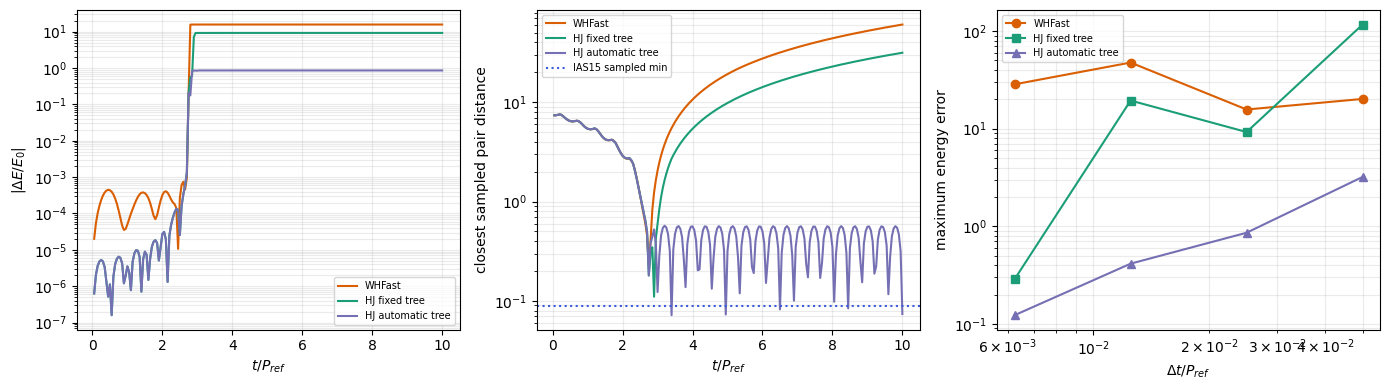

### Hierarchy-preserving eccentric 2+2 near miss

**Verdict:** fixed HJ better

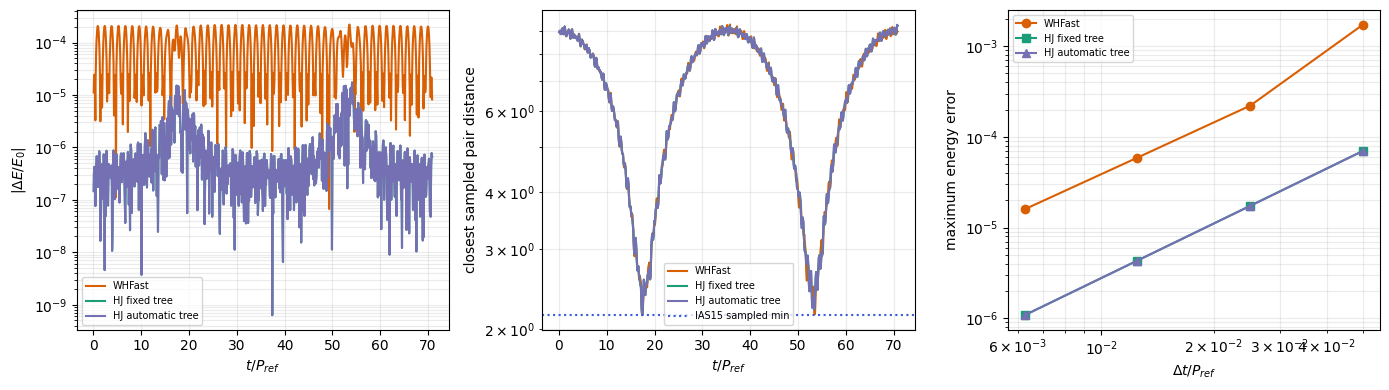

### Cross-branch planet encounter

**Verdict:** no reliable HJ win

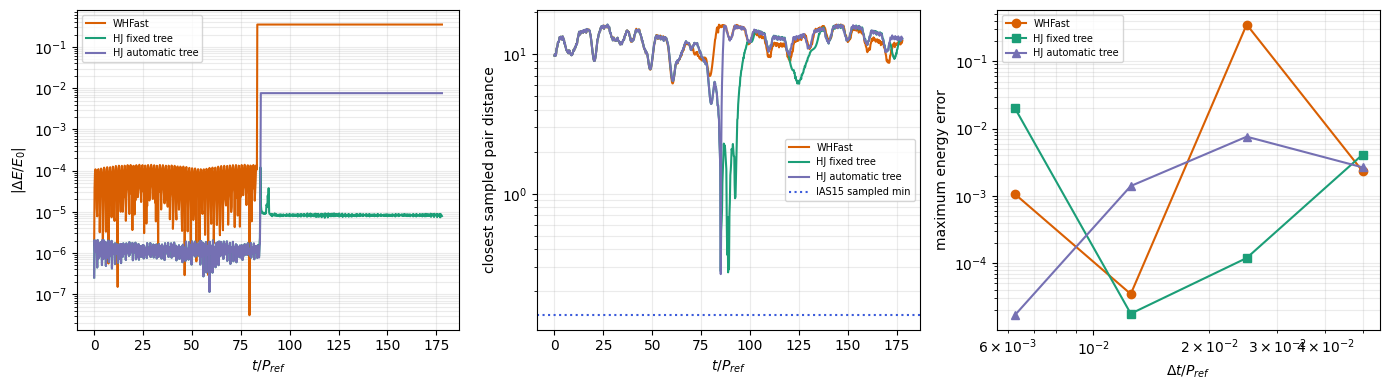

### Pythagorean three-body problem

**Verdict:** automatic HJ preferred

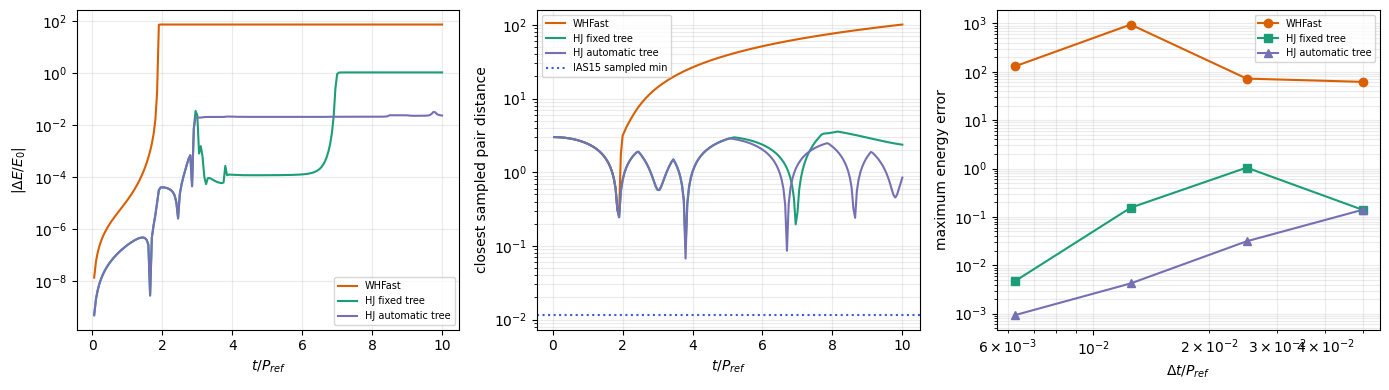

In [8]:
for case in CASES:
    display(Markdown(f"### {case.title}\n\n**Verdict:** {CLASSIFICATION[case.key]}"))
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    for mode in MODES:
        run=selected(case.key,mode)
        if run["failed"]: continue
        axes[0].plot(run["time"],run["energy"],label=LABELS[mode],color=COLORS[mode])
        axes[1].plot(run["time"],run["separation"],label=LABELS[mode],color=COLORS[mode])
    ref=REFERENCES[case.key]
    axes[1].axhline(ref["rmin"],color=COLORS["ias15"],ls=":",label="IAS15 sampled min")
    for mode,marker in (("whfast","o"),("hj_fixed","s"),("hj_auto","^")):
        rows=[r for r in RESULTS if r["case"]==case.key and r["mode"]==mode and not r["failed"]]
        rows.sort(key=lambda r:1/r["divisor"])
        axes[2].loglog([1/r["divisor"] for r in rows],[r["max_energy"] for r in rows],
                       marker+"-",color=COLORS[mode],label=LABELS[mode])
    axes[0].set_yscale("log"); axes[0].set_xlabel(r"$t/P_{ref}$"); axes[0].set_ylabel(r"$|\Delta E/E_0|$")
    axes[1].set_yscale("log"); axes[1].set_xlabel(r"$t/P_{ref}$"); axes[1].set_ylabel("closest sampled pair distance")
    axes[2].set_xlabel(r"$\Delta t/P_{ref}$"); axes[2].set_ylabel("maximum energy error")
    for ax in axes: ax.grid(alpha=.25,which="both"); ax.legend(fontsize=7)
    fig.tight_layout(); plt.show()

## Interpretation and limitations

### Observations from the current full run

- **Case 1 — two giant planets:** the fixed tree is the same comb used by ordinary WHFast, so the two fixed methods are identical and both miss the encounter outcome. Automatic HJ improves monotonically from $P_{\rm ref}/40$ to $P_{\rm ref}/160$; at `/160` its maximum energy error is about $1.8\times10^{-4}$ and its sampled closest approach is $2.21\times10^{-4}$ versus $2.05\times10^{-4}$ for IAS15. Its normalized velocity error remains about 0.30, so the post-encounter trajectory is not fully converged.
- **Case 2 — binary–single scattering:** ordinary WHFast and fixed HJ are again the same comb split. Automatic HJ first reproduces the pairwise outcome at `/160`, but its maximum energy error is still about 0.041 and `dv` is about 0.56. This is qualitative improvement, not a quantitatively reliable scattering solution.
- **Case 3 — binary–binary scattering:** none of the fixed-step methods reproduces the IAS15 outcome. Even at `/160`, maximum energy errors are about 28.5 for WHFast, 0.287 for fixed HJ, and 0.123 for automatic HJ. Automatic HJ is least inaccurate, but there is no reliable HJ win.
- **Case 4 — hierarchy-preserving eccentric 2+2 near miss:** this is the clean positive fixed-tree result. At `/40`, fixed HJ reduces maximum energy error from about $2.21\times10^{-4}$ to $1.74\times10^{-5}$ and RMS error from $1.13\times10^{-4}$ to $2.65\times10^{-6}$. It also reduces `dx` from about 0.039 to $1.0\times10^{-5}$, reduces `dv` from about 0.44 to $1.6\times10^{-4}$, and matches the IAS15 outcome. Its errors decrease by approximately a factor of four when the timestep is halved. Fixed and automatic HJ agree because the physical tree remains unchanged.
- **Case 5 — cross-branch planet encounter:** the results are non-monotonic. Different timesteps give different encounter geometries and outcomes; a small energy error at one timestep does not predict convergence. The initial tree has physically broken down, so neither fixed nor automatic HJ gives a reliable solution over the tested interval.
- **Case 6 — Pythagorean problem:** automatic HJ is much better than ordinary WHFast and improves steadily through `/160`, where its maximum energy error is about $9.3\times10^{-4}$ and `dx` is about $3.9\times10^{-3}$. However, its sampled closest approach is still about twice the IAS15 value and `dv` is about 0.11, so finer timesteps are required.

### Overall result

The experiments separate into three regimes. (1) When a genuinely branching hierarchy survives a near encounter, as in case 4, supplying that tree to HJ gives a large and clean accuracy improvement. (2) When the hierarchy changes but the encounter is moderately resolvable, automatic tree rebuilding can outperform a fixed tree, as in cases 1 and 6, although convergence must still be demonstrated. (3) In violent scattering or chaotic hierarchy breakdown, as in cases 2, 3, and 5, neither fixed nor automatic HJ is reliably sufficient at the tested timesteps. Tree adaptation helps the Hamiltonian split but does not replace a dedicated close-encounter solver.

Angular-momentum drift is near roundoff in many runs that nevertheless have wrong energies, encounter distances, and outcomes. Angular-momentum conservation alone is therefore not evidence of a correct scattering trajectory. The printed `automatic HJ preferred` verdict is also only qualitative: the current pairwise negative-energy outcome is a compact fingerprint, not a rigorous recursive hierarchy classification, and outcome agreement can occur even when the closest approach is inaccurate.

### Scope and limitations

- Fixed-tree HJ is expected to help only while the supplied Kepler pairs remain dynamically meaningful. A close approach by itself does not invalidate a tree, but exchange, ionization, or cross-branch penetration can.
- Automatic HJ can respond to a changed hierarchy, but rebuilding the split adds cost and a rapidly switching tree can introduce its own error.
- Fixed-step WHFast methods are not close-encounter integrators. A smaller timestep does not guarantee the same scattering outcome once trajectories diverge chaotically. For production planetary scattering, hybrid methods such as TRACE or MERCURIUS should be tested against IAS15.
- Agreement in energy is insufficient. The closest approach, encounter time, trajectory error, and final bound outcome must also agree with IAS15.
- `r_min` is sampled, so extremely brief encounters may be closer than reported. Event refinement around the IAS15 minimum is a natural next improvement.
- Binary scattering outcomes are chaotic. A single deterministic realization tests numerical behavior, not a physical cross section; literature studies use ensembles over phase, orientation, velocity, and impact parameter.
- The simple bound-pair fingerprint can list overlapping negative-energy pairs in a multi-body environment. A production analysis should recursively identify mutually bound subsystems and escaping bodies.
- Point masses have no physical collision radius, tides, relativity, or disruption. These tests isolate gravitational integration behavior.